## Week 4: Imbalance Data

## Load dataset

In [5]:
import pandas as pd
data = pd.read_csv(r"C:\Users\clift\Downloads\creditcard.csv")

In [6]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
data.shape

(284807, 31)

In [8]:
data.Class.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
# check the number of 1s and 0s
count = data['Class'].value_counts()

print('Fraudulent "1" :', count[1])
print('Not Fraudulent "0":', count[0])

# print the percentage of question where target == 1
print(count[1]/count[0]* 100)

Fraudulent "1" : 492
Not Fraudulent "0": 284315
0.17304750013189596


This show  that the data is highly imbalance. Only 0.17% of the data is belong to fraud

C:\Users\clift\AppData\Local\Temp\ipykernel_30836\8812608.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(['Not Fraud', 'Fraud'])


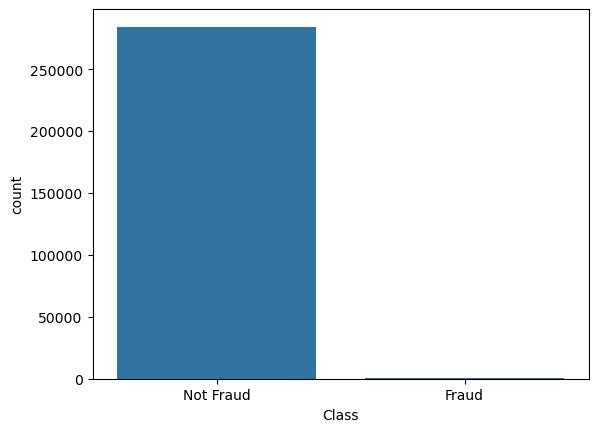

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
# plot the no of 1's and 0's
g = sns.countplot(x='Class',data=data)
g.set_xticklabels(['Not Fraud', 'Fraud'])
plt.show()

In [11]:
# check for null values
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Response and Target variable

In [12]:
import numpy as np
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

# check length of 1's and 0's
one = np.where(y==1)
zero = np.where(y==0)
len(one[0]), len(zero[0])

(492, 284315)

## Train test split

In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
Train_one = np.where(y_train==1)
Train_zero = np.where(y_train==0)
len(Train_one[0]), len(Train_zero[0])

(394, 227451)

In [15]:
Test_one = np.where(y_test==1)
Test_zero = np.where(y_test==0)
len(Test_one[0]), len(Test_zero[0])


(98, 56864)

## Fit the model using Logistic Regression

In [16]:
# create the object
from sklearn.linear_model import LogisticRegression
model =  LogisticRegression()

model.fit(x, y)

y_predict = model.predict(x)

C:\Users\clift\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
accuracy_score(y_predict, y)

0.9989115436067232

Accuray of 99.89% is achieved with this dataset. Let have a look of the confusion matrix

In [18]:
confusion_matrix(y_predict, y)

array([[284158,    153],
       [   157,    339]])

In [19]:
roc_auc_score(y_predict, y)

np.float64(0.8414647994228492)

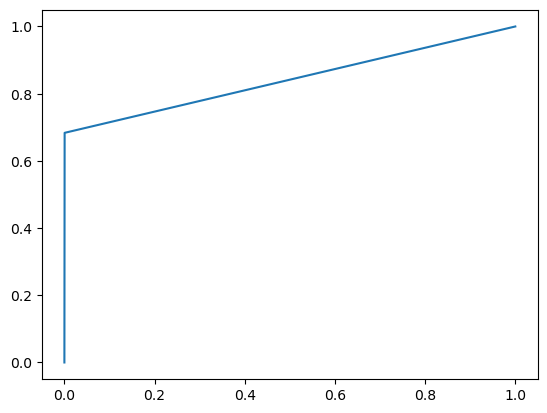

In [20]:
fpr, tpr, thresholds=roc_curve(y_predict, y)
plt.plot(fpr,tpr)

In [21]:
f1_score(y_predict, y)

0.6862348178137652

### What can you conclude from the confusion matrix, ROC and F1 score?

##  Resampling Technique

In [22]:
# class count
class_count_0, class_count_1 = data['Class'].value_counts()

# divie class
class_0 = data[data['Class'] == 0]
class_1 = data[data['Class'] == 1]

In [23]:
# print the shape of the class
print('class 0:', class_0.shape)
print('\nclass 1:', class_1.shape)

class 0: (284315, 31)

class 1: (492, 31)


## 1. Random under sampling

total class of 1 and 0:
 Class
0    492
1    492
Name: count, dtype: int64


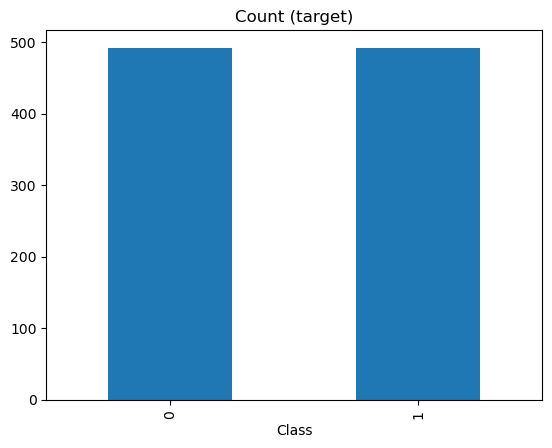

In [24]:
class_0_under = class_0.sample(class_count_1)

test_under = pd.concat([class_0_under, class_1], axis=0)

print("total class of 1 and 0:\n",test_under['Class'].value_counts())

test_under['Class'].value_counts().plot(kind='bar', title='Count (target)')
plt.show()

In [25]:
# Let split the data into train and testing
# Train the model using Logistic Regression
# Get the performance matrix: Accuray, Confusion matrix, ROC and F1 Score

## 2. Random over sampling

class count of 1 and 0:
 Class
1    284315
0    284315
Name: count, dtype: int64


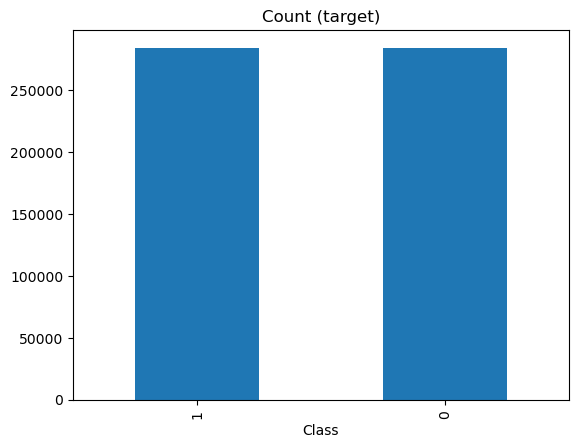

In [26]:
class_1_over = class_1.sample(class_count_0, replace=True)

test_under = pd.concat([class_1_over, class_0], axis=0)

# print the number of class count
print('class count of 1 and 0:\n', test_under['Class'].value_counts())

# plot the count
test_under['Class'].value_counts().plot(kind='bar', title='Count (target)')
plt.show()

In [27]:
# Let split the data into train and testing
# Train the model using Logistic Regression
# Get the performance matrix: Accuracy, Confusion matrix, ROC and F1 Score, ROC Curve



## Balance data with imbalance learn module

In [28]:
# import library
import imblearn

## 3. Random under-sampling with imblearn

In [29]:
# import library
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42, replacement=True)

# fit predictor and target varialbe
x_rus, y_rus = rus.fit_resample(x, y)

print('original dataset shape:', Counter(y))
print('Resample dataset shape', Counter(y_rus))

original dataset shape: Counter({0: 284315, 1: 492})
Resample dataset shape Counter({0: 492, 1: 492})


In [30]:
# Let split the data into train and testing
# Train the model using Logistic Regression
# Get the performance matrix: Accuracy, Confusion matrix, ROC and F1 Score, ROC Curve



## 4. Random over-sampling with imblearn

In [31]:
# import library
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

# fit predictor and target varaible
x_ros, y_ros = ros.fit_resample(x, y)

print('Original dataset shape', Counter(y))
print('Resample dataset shape', Counter(y_ros))

Original dataset shape Counter({0: 284315, 1: 492})
Resample dataset shape Counter({0: 284315, 1: 284315})


In [32]:
# Let split the data into train and testing
# Train the model using Logistic Regression
# Get the performance matrix: Accuracy, Confusion matrix, ROC and F1 Score, ROC Curve



## 5. Under-sampling Tomek links

In [33]:
# load library
from imblearn.under_sampling import TomekLinks

tl = TomekLinks(sampling_strategy='majority')

# fit predictor and target variable
x_tl, y_tl = tl.fit_resample(x, y)

print('Original dataset shape:', Counter(y))
print('Resample dataset shape:', Counter(y_tl))

C:\Users\clift\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\clift\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\clift\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\clift\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Original dataset shape: Counter({0: 284315, 1: 492})
Resample dataset shape: Counter({0: 284244, 1: 492})


In [34]:
# Let split the data into train and testing
# Train the model using Logistic Regression
# Get the performance matrix: Accuracy, Confusion matrix, ROC and F1 Score, ROC Curve



## 6. Synthetic minority over-sampling technique (SMOTE)

In [35]:
# load library
from imblearn.over_sampling import SMOTE

smote = SMOTE()

# fit target and predictor variable
x_smote , y_smote = smote.fit_resample(x, y)

print('Origianl dataset shape:', Counter(y))
print('Resampple dataset shape:', Counter(y_smote))

Origianl dataset shape: Counter({0: 284315, 1: 492})
Resampple dataset shape: Counter({0: 284315, 1: 284315})


In [36]:
# Let split the data into train and testing
# Train the model using Logistic Regression
# Get the performance matrix: Accuracy, Confusion matrix, ROC and F1 Score, ROC Curve



## 7. NearMiss

In [37]:
from imblearn.under_sampling import NearMiss

nm = NearMiss()

x_nm, y_nm = nm.fit_resample(x, y)

print('Original dataset shape:', Counter(y))
print('Resample dataset shape:', Counter(y_nm))

Original dataset shape: Counter({0: 284315, 1: 492})
Resample dataset shape: Counter({0: 492, 1: 492})


In [38]:
# Let split the data into train and testing
# Train the model using Logistic Regression
# Get the performance matrix: Accuracy, Confusion matrix, ROC and F1 Score, ROC Curve



Let check out what is NearMiss

## 8. penalize algorithm (cost-sensitive training)

In [39]:
"""
# load library
from sklearn.svm import SVC

# we can add class_weight='balanced' to add panalize mistake
svc_model = SVC(class_weight='balanced', probability=True)

svc_model.fit(x_train, y_train)

svc_predict = svc_model.predict(x_test)
"""

"\n# load library\nfrom sklearn.svm import SVC\n\n# we can add class_weight='balanced' to add panalize mistake\nsvc_model = SVC(class_weight='balanced', probability=True)\n\nsvc_model.fit(x_train, y_train)\n\nsvc_predict = svc_model.predict(x_test)\n"

In [40]:
# Let split the data into train and testing
# Train the model using Logistic Regression
# Get the performance matrix: Accuracy, Confusion matrix, ROC and F1 Score, ROC Curve



## 10. Tree based algorithm

While in every machine learning problem, it’s a good rule of thumb to try a variety of algorithms, it can be especially beneficial with imbalanced datasets.

Decision trees frequently perform well on imbalanced data. In modern machine learning, tree ensembles (Random Forests, Gradient Boosted Trees, etc.) almost always outperform singular decision trees, so we’ll jump right into those:

Tree base algorithm work by learning a hierarchy of if/else questions. This can force both classes to be addressed.

In [41]:
# Let Train the model using Random Forest
# Get the performance matrix: Accuracy, Confusion matrix, ROC and F1 Score, ROC Curve
# fit the predictor and target

In [42]:
# Let Train the model using XGBoost
# Get the performance matrix: Accuracy, Confusion matrix, ROC and F1 Score, ROC Curve
# fit the predictor and target

What is the advantages and disadvantage of using under-sampling and over-sampling?